<a href="https://colab.research.google.com/github/Likelipop/algorithm-analysis/blob/main/Lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BTTH TUẦN 8
--
Tên: Trần Tiến Đạt

MSSV: 22110039

# Bài 1

## ĐỀ BÀI

Ta xây dựng một dãy các từ Fibonacci như sau:

- `f0 = "abc"`
- `f1 = "def"`
- `f(n+1) = strcat(fn, f(n-1)), với n ≥ 1`

Trong đó, hàm `strcat` là hàm nối hai chuỗi thành một chuỗi mới.

Ví dụ:

```text
strcat("abc", "def") = "abcdef"

## TRIỂN KHAI

### 2.1 Nhận xét

Theo định nghĩa:

```text
fn = f(n-1) + f(n-2)
```

Do đó:

* Phần đầu của `fn` chính là `f(n-1)`
* Phần sau của `fn` chính là `f(n-2)`

Độ dài của chuỗi cũng thỏa:

```text
len(fn) = len(f(n-1)) + len(f(n-2))
```

Vì vậy, để tìm ký tự thứ `k` trong `fn`, ta chỉ cần xác định:

* `k` nằm trong phần `f(n-1)` hay
* nằm trong phần `f(n-2)`

---

## 3. Tiền xử lý độ dài các chuỗi

Thuật toán không tạo trực tiếp các chuỗi Fibonacci vì kích thước tăng rất nhanh.

Thay vào đó, ta chỉ lưu:

```python
length[i] = độ dài của fi
```

với công thức:

```python
length[i] = length[i - 1] + length[i - 2]
```

Điều này giúp xác định nhanh vị trí của ký tự cần tìm.

---

## 4. Chi tiết thuật toán truy hồi

Giả sử cần tìm ký tự thứ `k` trong `fn`.

### Trường hợp cơ sở

* Nếu `n == 0` → trả về `f0[k]`
* Nếu `n == 1` → trả về `f1[k]`

---

### Trường hợp truy hồi

Do:

```text
fn = f(n-1) + f(n-2)
```

nên:

* Nếu `k < length[n-1]`

  → ký tự cần tìm nằm trong `f(n-1)`

  → gọi đệ quy:

```python
get_char(n - 1, k)
```

* Ngược lại

  → ký tự nằm trong `f(n-2)`

  → bỏ qua phần `f(n-1)` nên cập nhật vị trí:

```python
k = k - length[n-1]
```

→ gọi:

```python
get_char(n - 2, k - length[n - 1])
```


In [1]:
import time
import matplotlib.pyplot as plt
import seaborn as sns

f0 = "abc"
f1 = "def"

# =========================
# Tính độ dài các chuỗi Fibonacci
# =========================

MAX_N = 100

length = [0] * (MAX_N + 1)

length[0] = len(f0)
length[1] = len(f1)

for i in range(2, MAX_N + 1):
    length[i] = length[i - 1] + length[i - 2]


# =========================
# Hàm tìm ký tự thứ k của f(n)
# =========================

def get_char(n, k):
    """
    Hàm giải quyết bài toán trên ( lấy ký tự thứ k của f_n )
    """

    # Kiểm tra hợp lệ
    if k < 0 or k >= length[n]:
        return "Index out of range"

    # Base cases
    if n == 0:
        return f0[k]

    if n == 1:
        return f1[k]

    # Recursive cases
    if k < length[n - 1]:
        return get_char(n - 1, k)
    else:
        return get_char(n - 2, k - length[n - 1])



## Test

In [2]:
n = 2
k = 5

print("Độ dài f(", n, ") =", length[n])
print("Ký tự thứ", k, "của f(", n, ") là:", get_char(n, k))

Độ dài f( 2 ) = 6
Ký tự thứ 5 của f( 2 ) là: c


# ĐỘ PHỨC TẠP

## Cố định k, chạy n


Ta thấy rằng với k cố định , n tăng dần, thời gian thực hiện thuật toán dần như thể hiện được mối quan hệ tuyến tính.

n =  8 | avg_time = 0.0000009676 s
n =  9 | avg_time = 0.0000012798 s
n = 10 | avg_time = 0.0000011440 s
n = 11 | avg_time = 0.0000012628 s
n = 12 | avg_time = 0.0000015290 s
n = 13 | avg_time = 0.0000016382 s
n = 14 | avg_time = 0.0000017096 s
n = 15 | avg_time = 0.0000017531 s
n = 16 | avg_time = 0.0000018929 s
n = 17 | avg_time = 0.0000020980 s
n = 18 | avg_time = 0.0000021348 s
n = 19 | avg_time = 0.0000022954 s
n = 20 | avg_time = 0.0000024420 s
n = 21 | avg_time = 0.0000026511 s
n = 22 | avg_time = 0.0000026409 s
n = 23 | avg_time = 0.0000027171 s
n = 24 | avg_time = 0.0000028592 s
n = 25 | avg_time = 0.0000029987 s
n = 26 | avg_time = 0.0000031082 s
n = 27 | avg_time = 0.0000038492 s
n = 28 | avg_time = 0.0000034190 s
n = 29 | avg_time = 0.0000040180 s
n = 30 | avg_time = 0.0000035564 s
n = 31 | avg_time = 0.0000036539 s
n = 32 | avg_time = 0.0000040803 s
n = 33 | avg_time = 0.0000039148 s
n = 34 | avg_time = 0.0000044870 s
n = 35 | avg_time = 0.0000041694 s
n = 36 | avg_time = 

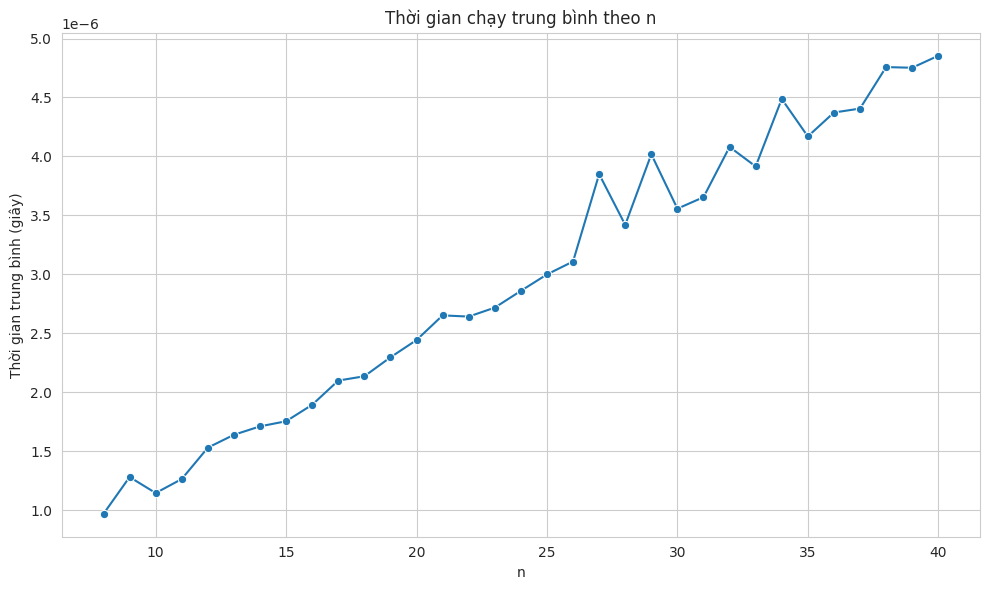

In [21]:
MAX_N = 40

k = 100

NUM_TRIALS = 100

n_values = []
time_values = []

for n in range(2, MAX_N + 1):

    if k >= length[n]:
        continue

    total_time = 0

    for _ in range(NUM_TRIALS):

        start = time.perf_counter()

        get_char(n, k)

        end = time.perf_counter()

        total_time += (end - start)

    avg_time = total_time / NUM_TRIALS

    n_values.append(n)
    time_values.append(avg_time)

    print(f"n = {n:2d} | avg_time = {avg_time:.10f} s")


# =========================
# Vẽ biểu đồ
# =========================

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=n_values,
    y=time_values,
    marker="o"
)

plt.title("Thời gian chạy trung bình theo n")
plt.xlabel("n")
plt.ylabel("Thời gian trung bình (giây)")

plt.tight_layout()
plt.show()

## Cố định n, chạy k

Ngược lại với k tăng dần, ta thấy rằng thời gian thực thi và k không thể hiện được mối liên hệ rõ ràng

range(0, 364179)
k =      0 | avg_time = 0.0000046874 s
k =   5000 | avg_time = 0.0000030747 s
k =  10000 | avg_time = 0.0000028050 s
k =  15000 | avg_time = 0.0000047373 s
k =  20000 | avg_time = 0.0000025901 s
k =  25000 | avg_time = 0.0000027965 s
k =  30000 | avg_time = 0.0000028621 s
k =  35000 | avg_time = 0.0000029705 s
k =  40000 | avg_time = 0.0000035760 s
k =  45000 | avg_time = 0.0000047564 s
k =  50000 | avg_time = 0.0000026632 s
k =  55000 | avg_time = 0.0000029878 s
k =  60000 | avg_time = 0.0000028187 s
k =  65000 | avg_time = 0.0000028738 s
k =  70000 | avg_time = 0.0000028119 s
k =  75000 | avg_time = 0.0000029311 s
k =  80000 | avg_time = 0.0000027137 s
k =  85000 | avg_time = 0.0000027019 s
k =  90000 | avg_time = 0.0000029385 s
k =  95000 | avg_time = 0.0000030344 s
k = 100000 | avg_time = 0.0000029327 s
k = 105000 | avg_time = 0.0000026522 s
k = 110000 | avg_time = 0.0000027867 s
k = 115000 | avg_time = 0.0000029279 s
k = 120000 | avg_time = 0.0000028484 s
k = 1250

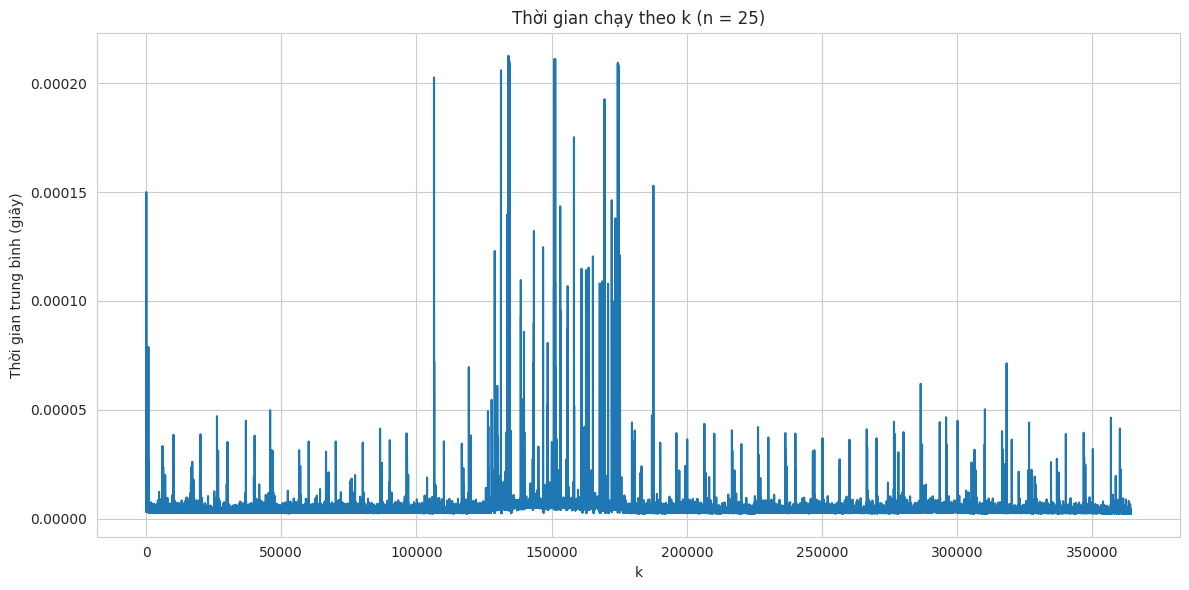

In [26]:
FIXED_N = 25

NUM_TRIALS = 10

k_values = []
time_values = []

print(range(length[FIXED_N]))
for k in range(length[FIXED_N]):

    total_time = 0

    for _ in range(NUM_TRIALS):

        start = time.perf_counter()

        get_char(FIXED_N, k)

        end = time.perf_counter()

        total_time += (end - start)

    avg_time = total_time / NUM_TRIALS

    k_values.append(k)
    time_values.append(avg_time)

    if k % 5000 == 0:
        print(f"k = {k:6d} | avg_time = {avg_time:.10f} s")


# =========================
# Vẽ biểu đồ
# =========================

sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=k_values,
    y=time_values
)

plt.title(f"Thời gian chạy theo k (n = {FIXED_N})")
plt.xlabel("k")
plt.ylabel("Thời gian trung bình (giây)")

plt.tight_layout()
plt.show()

# Phân tích độ phức tạp của thuật toán tìm ký tự trong dãy Fibonacci chuỗi

Xét bài toán xác định ký tự thứ $k$ của chuỗi Fibonacci ký hiệu $f_n$, được định nghĩa bởi quan hệ truy hồi:

$$
f_n = f_{n-1} \cdot f_{n-2}
$$

trong đó phép $\cdot$ là phép nối chuỗi.

Từ định nghĩa này, ta nhận thấy rằng mỗi chuỗi $f_n$ không được hình thành một cách độc lập, mà luôn được cấu trúc từ hai chuỗi con có bậc thấp hơn là $f_{n-1}$ và $f_{n-2}$. Cụ thể, phần đầu của $f_n$ chính là $f_{n-1}$, trong khi phần còn lại tương ứng với $f_{n-2}$. Đây là một tính chất mang tính phân hoạch tự nhiên của bài toán, cho phép ta định vị ký tự mà không cần xây dựng toàn bộ chuỗi.

Để xác định ký tự thứ $k$ trong $f_n$, ta xét độ dài của $f_{n-1}$, ký hiệu $|f_{n-1}|$. Nếu $k < |f_{n-1}|$, ký tự cần tìm nằm hoàn toàn trong phần $f_{n-1}$, do đó bài toán được quy về việc tìm ký tự thứ $k$ trong $f_{n-1}$. Ngược lại, nếu $k \ge |f_{n-1}|$, ta suy ra ký tự thuộc về phần $f_{n-2}$. Khi đó, do đã loại bỏ toàn bộ phần $f_{n-1}$ đứng trước, ta cần điều chỉnh lại vị trí bằng cách đặt $k' = k - |f_{n-1}|$, và bài toán được quy về tìm ký tự thứ $k'$ trong $f_{n-2}$.

Điểm quan trọng là mỗi bước xử lý chỉ dẫn đến đúng một bài toán con duy nhất. Thuật toán không phân nhánh đồng thời mà luôn chọn một hướng duy nhất dựa trên vị trí $k$. Vì vậy, quá trình truy hồi hình thành một chuỗi lời gọi đơn tuyến tính theo chỉ số $n$, phản ánh cấu trúc phân rã tuần tự của bài toán.

Xét về độ phức tạp thời gian, gọi $T(n)$ là thời gian thực hiện thuật toán với đầu vào $n$. Trong mỗi bước đệ quy, thuật toán thực hiện một số hữu hạn phép toán cơ bản bao gồm so sánh, truy cập mảng và phép gán, do đó chi phí mỗi bước là hằng số, tức $\Theta(1)$. Đồng thời, bài toán con được giảm về $n-1$ hoặc $n-2$. Trong trường hợp xấu nhất, ta có quan hệ:

$$
T(n) \le T(n-1) + c
$$

với $c$ là hằng số dương. Khai triển truy hồi, ta thu được:

$$
T(n) \le T(1) + (n-1)c
$$

Suy ra:

$$
T(n) = \Theta(n)
$$

Điều này cho thấy thời gian xử lý tăng tuyến tính theo $n$, bất kể kích thước thực tế của chuỗi $f_n$ có thể tăng rất nhanh.

Về mặt bộ nhớ, thuật toán sử dụng hai thành phần chính. Thứ nhất là mảng lưu trước độ dài các chuỗi $f_i$ từ $0$ đến $n$, dẫn đến chi phí bộ nhớ $\Theta(n)$. Thứ hai là ngăn xếp đệ quy, với độ sâu tối đa tương ứng với số lần giảm chỉ số $n$, do mỗi bước giảm ít nhất một đơn vị. Vì vậy, độ sâu ngăn xếp cũng là $\Theta(n)$. Tổng hợp lại, ta có:

$$
S(n) = \Theta(n)
$$

Từ các phân tích trên, kết luận rằng thuật toán đạt độ phức tạp thời gian tuyến tính và bộ nhớ tuyến tính:

$$
T(n) = \Theta(n), \quad S(n) = \Theta(n)
$$

Ý nghĩa quan trọng của kết quả này nằm ở chỗ nó khai thác được cấu trúc truy hồi của chuỗi Fibonacci để tránh việc xây dựng trực tiếp chuỗi. Nếu thực hiện xây dựng toàn bộ $f_n$, độ dài chuỗi sẽ tăng theo cấp số mũ xấp xỉ $\varphi^n$ với $\varphi$ là tỉ lệ vàng, dẫn đến chi phí thời gian và bộ nhớ không khả thi. Ngược lại, thuật toán hiện tại chuyển bài toán từ tăng trưởng mũ sang tăng trưởng tuyến tính bằng cách khai thác tính chất phân rã cấu trúc của dãy.
```